In [2]:
!pip install kagglehub

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 4.3 MB/s eta 0:00:00

[notice] A new release of pip is available: 24.1.2 -> 24.3.1
[notice] To update, run: pip install --upgrade pip


In [5]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
pdavpoojan_the_rvlcdip_dataset_test_path = kagglehub.dataset_download('pdavpoojan/the-rvlcdip-dataset-test')

print('Data source import complete.')


Download already complete (3884735325 bytes).
Extracting files...
Data source import complete.


<img src="https://images.unsplash.com/photo-1532153975070-2e9ab71f1b14?ixlib=rb-1.2.1&dl=annie-spratt-5cFwQ-WMcJU-unsplash.jpg&w=1920&q=80&fm=jpg&crop=entropy&cs=tinysrgb">


## 1. Introduction:
* This notebook is a tutorial to the multi-modal architecture DocFormer (mainly for the purpose of Document Understanding).
* We would take in, the test-images of the RVL-CDIP Dataset, and then would train the model on a subset of the dataset
* We would also be logging the metrics with the help of Weights and Biases

## A small Introduction about the Model:

<img src = "https://github.com/uakarsh/docformer/raw/master/images/docformer-architecture.png">

DocFormer is a multi-modal transformer based architecture for the task of Visual Document Understanding (VDU). In addition, DocFormer is pre-trained in an unsupervised fashion using carefully designed tasks which encourage multi-modal interaction. DocFormer uses text, vision and spatial features and combines them using a novel multi-modal self-attention layer. DocFormer also shares learned spatial embeddings across modalities which makes it easy for the model to correlate text to visual tokens and vice versa. DocFormer is evaluated on 4 different datasets each with strong baselines. DocFormer achieves state-of-the-art results on all of them, sometimes beating models 4x its size (in no. of parameters).

For more understanding of the model and its code implementation, one can visit [here](https://github.com/uakarsh/docformer). So, let us go on to see what this model has to offer

The report for this entire run is attached [here](https://wandb.ai/iakarshu/RVL%20CDIP%20with%20DocFormer%20New%20Version/reports/Performance-of-DocFormer-with-RVL-CDIP-Test-Dataset--VmlldzoyMTI3NTM4)

<img src = "https://drive.google.com/u/1/uc?id=1IOyYXbU8bi5FDq59Z4RI1Qkoc54CzZto&export=download" >




### An Interactive Demo for the same can be found on 🤗 space [here](https://huggingface.co/spaces/iakarshu/docformer_for_document_classification)

### Installing the Libraries ⚙️:

didn't RUN


In [ ]:
## Installing the dependencies (might take some time)

!pip install -q pytesseract
!sudo apt install  -q tesseract-ocr
!pip install  -q transformers
!pip install  -q pytorch-lightning
!pip install  -q einops
!pip install  -q tqdm
!pip install  -q 'Pillow==7.1.2'
!pip install  -q datasets
!pip install wandb
!pip install torchmetrics

Reading package lists...
Building dependency tree...
Reading state information...
The following additional packages will be installed:
  tesseract-ocr-eng tesseract-ocr-osd
The following NEW packages will be installed:
  tesseract-ocr tesseract-ocr-eng tesseract-ocr-osd
0 upgraded, 3 newly installed, 0 to remove and 49 not upgraded.
Need to get 4,816 kB of archives.
After this operation, 15.6 MB of additional disk space will be used.
Get:1 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-eng all 1:4.00~git30-7274cfa-1.1 [1,591 kB]
Get:2 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr-osd all 1:4.00~git30-7274cfa-1.1 [2,990 kB]
Get:3 http://archive.ubuntu.com/ubuntu jammy/universe amd64 tesseract-ocr amd64 4.1.1-2.1build1 [236 kB]
Fetched 4,816 kB in 0s (27.2 MB/s)
debconf: unable to initialize frontend: Dialog
debconf: (No usable dialog-like program is installed, so the dialog based frontend cannot be used. at /usr/share/perl5/Debconf/FrontEnd/Dia

didn't RUN


In [ ]:
## Cloning the repository
!git clone https://github.com/uakarsh/docformer.git

Cloning into 'docformer'...
remote: Enumerating objects: 1418, done.
remote: Counting objects: 100% (352/352), done.
remote: Compressing objects: 100% (162/162), done.
remote: Total 1418 (delta 223), reused 251 (delta 161), pack-reused 1066 (from 1)
Receiving objects: 100% (1418/1418), 4.96 MiB | 9.19 MiB/s, done.
Resolving deltas: 100% (754/754), done.


didn't RUN


didn't RUN


In [ ]:
!pip install  -q einops

didn't RUN


In [ ]:
## Logging into wandb

import wandb
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
# secret_value_0 = user_secrets.get_secret("wandb_api")
wandb.login(key='6c428751732ed20a729a5ae1d3ee7834520e985e')

## 2. Libraries 📘:

didn't RUN


In [ ]:
!pip install --upgrade Pillow


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.4/4.4 MB 29.0 MB/s eta 0:00:00
  Attempting uninstall: Pillow
    Found existing installation: Pillow 7.1.2
    Uninstalling Pillow-7.1.2:
      Successfully uninstalled Pillow-7.1.2


In [7]:
## Importing the libraries

import warnings
warnings.simplefilter("ignore", UserWarning)
warnings.simplefilter("ignore", RuntimeWarning)

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import pandas as pd

import torch
import torch.nn as nn
from torch.utils.data import Dataset,DataLoader

import torch.nn.functional as F
import torchvision.models as models

## Adding the path of docformer to system path
import sys
# sys.path.append('./docformer/src/docformer/')
sys.path.append('./src/docformer')

## Importing the functions from the DocFormer Repo
# from dataset import create_features
from modeling import DocFormerEncoder,ResNetFeatureExtractor,DocFormerEmbeddings,LanguageFeatureExtractor
from transformers import BertTokenizerFast

In [8]:
## Hyperparameters

seed = 42
target_size = (500, 384) # (1280, 960)

## Setting some hyperparameters

device = 'cuda' if torch.cuda.is_available() else 'cpu'

## One can change this configuration and try out new combination
config = {
  "coordinate_size": 96,              ## (768/8), 8 for each of the 8 coordinates of x, y
  "hidden_dropout_prob": 0.1,
  "hidden_size": 768,
  "image_feature_pool_shape": [7, 7, 256],
  "intermediate_ff_size_factor": 4,
  "max_2d_position_embeddings": 1024,
  "max_position_embeddings": 128,
  "max_relative_positions": 8,
  "num_attention_heads": 12,
  "num_hidden_layers": 12,
  "pad_token_id": 0,
  "shape_size": 96,
  "vocab_size": 30522,
  "layer_norm_eps": 1e-12,
}

## A small note 🗒️:
Here, for the purpose of Demo I would be using only 250 Images per class, and would train the model on it. Definintely for a data hungry model such as transformers, such a small data is not enough, but let us see what are the results on it.

In [9]:
from datasets import load_dataset

dataset = load_dataset("nielsr/rvl_cdip_10_examples_per_class")

Generating test split: 100%|██████████| 160/160 [00:00<00:00, 3219.55 examples/s]


In [10]:
dataset

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 160
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 160
    })
})

In [11]:
dataset['train']['label'][0]

0

In [12]:
dataset['train'].features['label'].names

['letter',
 'form',
 'email',
 'handwritten',
 'advertisement',
 'scientific report',
 'scientific publication',
 'specification',
 'file folder',
 'news article',
 'budget',
 'invoice',
 'presentation',
 'questionnaire',
 'resume',
 'memo']

In [13]:
id2label = {id: label for id, label in enumerate(dataset['train'].features['label'].names)}
print(id2label)

{0: 'letter', 1: 'form', 2: 'email', 3: 'handwritten', 4: 'advertisement', 5: 'scientific report', 6: 'scientific publication', 7: 'specification', 8: 'file folder', 9: 'news article', 10: 'budget', 11: 'invoice', 12: 'presentation', 13: 'questionnaire', 14: 'resume', 15: 'memo'}


In [ ]:
from tqdm.auto import tqdm

## For the purpose of prediction
# id2label = []
# label2id = {}

# curr_class = 0
## Preparing the Dataset
# base_directory = '../input/the-rvlcdip-dataset-test/test'
# dict_of_img_labels = {'img':[], 'label':[]}

# max_sample_per_class = 250

# for label in tqdm(os.listdir(base_directory)):
#     img_path = os.path.join(base_directory, label)

#     count = 0
#     if label not in label2id:
#         label2id[label] = curr_class
#         curr_class+=1
#         id2label.append(label)

#     for img in os.listdir(img_path):
#         if count>max_sample_per_class:
#             break

#         curr_img_path = os.path.join(img_path, img)
#         dict_of_img_labels['img'].append(curr_img_path)
#         dict_of_img_labels['label'].append(label2id[label])
#         count+=1

In [14]:
dataset_train = dataset['train']

In [15]:
dataset_train

Dataset({
    features: ['image', 'label'],
    num_rows: 160
})

In [16]:
dataset_test = dataset['test']

In [17]:
dataset_train

Dataset({
    features: ['image', 'label'],
    num_rows: 160
})

In [18]:
import pandas as pd
train_df = pd.DataFrame(dataset_train)
valid_df = pd.DataFrame(dataset_test)

In [19]:
train_df = train_df.rename(columns={"image":"img"})
valid_df = valid_df.rename(columns={"image":"img"})

In [ ]:
train_df

,img,label
0,<PIL.Image.Image image mode=L size=762x1000 at...,0
1,<PIL.Image.Image image mode=L size=777x1000 at...,0
2,<PIL.Image.Image image mode=L size=783x1000 at...,0
3,<PIL.Image.Image image mode=L size=754x1000 at...,0
4,<PIL.Image.Image image mode=L size=803x1000 at...,0
...,...,...
155,<PIL.Image.Image image mode=L size=762x1000 at...,15
156,<PIL.Image.Image image mode=L size=762x1000 at...,15
157,<PIL.Image.Image image mode=L size=754x1000 at...,15
158,<PIL.Image.Image image mode=L size=777x1000 at...,15


In [20]:
valid_df

,img,label
0,<PIL.Image.Image image mode=L size=778x1000 at...,0
1,<PIL.Image.Image image mode=L size=754x1000 at...,0
2,<PIL.Image.Image image mode=L size=754x1000 at...,0
3,<PIL.Image.Image image mode=L size=770x1000 at...,0
4,<PIL.Image.Image image mode=L size=777x1000 at...,0
...,...,...
155,<PIL.Image.Image image mode=L size=861x1000 at...,15
156,<PIL.Image.Image image mode=L size=781x1000 at...,15
157,<PIL.Image.Image image mode=L size=774x1000 at...,15
158,<PIL.Image.Image image mode=L size=777x1000 at...,15


In [ ]:
# from sklearn.model_selection import train_test_split as tts
# train_df, valid_df = tts(df, random_state = seed, stratify = df['label'], shuffle = True)

In [21]:
train_df = train_df.reset_index().drop(columns = ['index'], axis = 1)
valid_df = valid_df.reset_index().drop(columns = ['index'], axis = 1)

In [22]:
train_df

,img,label
0,<PIL.Image.Image image mode=L size=762x1000 at...,0
1,<PIL.Image.Image image mode=L size=777x1000 at...,0
2,<PIL.Image.Image image mode=L size=783x1000 at...,0
3,<PIL.Image.Image image mode=L size=754x1000 at...,0
4,<PIL.Image.Image image mode=L size=803x1000 at...,0
...,...,...
155,<PIL.Image.Image image mode=L size=762x1000 at...,15
156,<PIL.Image.Image image mode=L size=762x1000 at...,15
157,<PIL.Image.Image image mode=L size=754x1000 at...,15
158,<PIL.Image.Image image mode=L size=777x1000 at...,15


In [ ]:
valid_df

,img,label
0,<PIL.Image.Image image mode=L size=778x1000 at...,0
1,<PIL.Image.Image image mode=L size=754x1000 at...,0
2,<PIL.Image.Image image mode=L size=754x1000 at...,0
3,<PIL.Image.Image image mode=L size=770x1000 at...,0
4,<PIL.Image.Image image mode=L size=777x1000 at...,0
...,...,...
155,<PIL.Image.Image image mode=L size=861x1000 at...,15
156,<PIL.Image.Image image mode=L size=781x1000 at...,15
157,<PIL.Image.Image image mode=L size=774x1000 at...,15
158,<PIL.Image.Image image mode=L size=777x1000 at...,15


## 3. Making the dataset 💽:

The main idea behind making the dataset is, to pre-process the input into a given format, and then provide the input to the model. So, simply just the image path, and the other configurations, and boom 💥, you would get the desired pre-processed input

In [23]:
(valid_df['img'][0]).size

(778, 1000)

In [24]:
def get_topleft_bottomright_coordinates(df_row):
    left, top, width, height = df_row["left"], df_row["top"], df_row["width"], df_row["height"]
    return [left, top, left + width, top + height]

In [25]:
def apply_ocr(image):
    """
    Returns words and its bounding boxes from an image
    """
#     image = Image.open(image_fp)
    width, height = image.size

    ocr_df = pytesseract.image_to_data(image, output_type="data.frame")
    ocr_df = ocr_df.dropna().reset_index(drop=True)
    float_cols = ocr_df.select_dtypes("float").columns
    ocr_df[float_cols] = ocr_df[float_cols].round(0).astype(int)
    ocr_df = ocr_df.replace(r"^\s*$", np.nan, regex=True)
    ocr_df = ocr_df.dropna().reset_index(drop=True)
    words = list(ocr_df.text.apply(lambda x: str(x).strip()))
    actual_bboxes = ocr_df.apply(get_topleft_bottomright_coordinates, axis=1).values.tolist()

    # add as extra columns
    assert len(words) == len(actual_bboxes)
    return {"words": words, "bbox": actual_bboxes}

In [26]:
def normalize_box(box, width, height, size=1000):
    """
    Takes a bounding box and normalizes it to a thousand pixels. If you notice it is
    just like calculating percentage except takes 1000 instead of 100.
    """
    return [
        int(size * (box[0] / width)),
        int(size * (box[1] / height)),
        int(size * (box[2] / width)),
        int(size * (box[3] / height)),
    ]


In [28]:
def get_tokens_with_boxes(unnormalized_word_boxes, pad_token_box, word_ids,max_seq_len = 512):

    # assert len(unnormalized_word_boxes) == len(word_ids), this should not be applied, since word_ids may have higher
    # length and the bbox corresponding to them may not exist

    unnormalized_token_boxes = []

    for i, word_idx in enumerate(word_ids):
        if word_idx is None:
            break
        unnormalized_token_boxes.append(unnormalized_word_boxes[word_idx])

    # all remaining are padding tokens so why add them in a loop one by one
    num_pad_tokens = len(word_ids) - i - 1
    if num_pad_tokens > 0:
        unnormalized_token_boxes.extend([pad_token_box] * num_pad_tokens)


    if len(unnormalized_token_boxes)<max_seq_len:
        unnormalized_token_boxes.extend([pad_token_box] * (max_seq_len-len(unnormalized_token_boxes)))

    return unnormalized_token_boxes[:max_seq_len] ## maybe in case the length is higher than max_seq_len

In [29]:
def resize_align_bbox(bbox, orig_w, orig_h, target_w, target_h):
    x_scale = target_w / orig_w
    y_scale = target_h / orig_h
    orig_left, orig_top, orig_right, orig_bottom = bbox
    x = int(np.round(orig_left * x_scale))
    y = int(np.round(orig_top * y_scale))
    xmax = int(np.round(orig_right * x_scale))
    ymax = int(np.round(orig_bottom * y_scale))
    return [x, y, xmax, ymax]

In [30]:
def get_centroid(actual_bbox):
    centroid = []
    for i in actual_bbox:
        width = i[2] - i[0]
        height = i[3] - i[1]
        centroid.append([i[0] + width / 2, i[1] + height / 2])
    return centroid

In [31]:
def get_pad_token_id_start_index(words, encoding, tokenizer):
#     assert len(words) < len(encoding["input_ids"])  This condition, was creating errors on some sample images
    for idx in range(len(encoding["input_ids"])):
        if encoding["input_ids"][idx] == tokenizer.pad_token_id:
            break
    return idx

In [32]:
def get_relative_distance(bboxes, centroids, pad_tokens_start_idx):

    a_rel_x = []
    a_rel_y = []

    for i in range(0, len(bboxes)-1):
        if i >= pad_tokens_start_idx:
            a_rel_x.append([0] * 8)
            a_rel_y.append([0] * 8)
            continue

        curr = bboxes[i]
        next = bboxes[i+1]

        a_rel_x.append(
            [
                curr[0],  # top left x
                curr[2],  # bottom right x
                curr[2] - curr[0],  # width
                next[0] - curr[0],  # diff top left x
                next[0] - curr[0],  # diff bottom left x
                next[2] - curr[2],  # diff top right x
                next[2] - curr[2],  # diff bottom right x
                centroids[i+1][0] - centroids[i][0],
            ]
        )

        a_rel_y.append(
            [
                curr[1],  # top left y
                curr[3],  # bottom right y
                curr[3] - curr[1],  # height
                next[1] - curr[1],  # diff top left y
                next[3] - curr[3],  # diff bottom left y
                next[1] - curr[1],  # diff top right y
                next[3] - curr[3],  # diff bottom right y
                centroids[i+1][1] - centroids[i][1],
            ]
        )

    # For the last word

    a_rel_x.append([0]*8)
    a_rel_y.append([0]*8)


    return a_rel_x, a_rel_y

In [33]:
# -*- coding: utf-8 -*-
import os
import pickle
from functools import lru_cache
import pytesseract
import numpy as np
from PIL import Image
import torch
from torchvision.transforms import ToTensor

PAD_TOKEN_BOX = [0, 0, 0, 0]
GRID_SIZE = 1000

def create_features(
        image,
        tokenizer,
        add_batch_dim=False,
        target_size=(500, 384),  # This was the resolution used by the authors
        max_seq_length=512,
        path_to_save=None,
        save_to_disk=False,
        apply_mask_for_mlm=False,
        extras_for_debugging=False,
        use_ocr = True,
        bounding_box = None,
        words = None
):

    # step 1: read original image and extract OCR entries
    try:
#         original_image = Image.open(image).convert("RGB")
        original_image = image.convert("RGB")
    except:
        original_image = Image.new(mode = "RGB", size = ((500, 500)), color = (255, 255, 255))
    if (use_ocr == False) and (bounding_box == None or words == None):
        raise Exception('Please provide the bounding box and words or pass the argument "use_ocr" = True')

    if use_ocr == True:
      entries = apply_ocr(image)
      bounding_box = entries["bbox"]
      words = entries["words"]

    CLS_TOKEN_BOX = [0, 0, *original_image.size]    # Can be variable, but as per the paper, they have mentioned that it covers the whole image
    # step 2: resize image
    resized_image = original_image.resize(target_size)
#     display(resized_image)

    # step 3: normalize image to a grid of 1000 x 1000 (to avoid the problem of differently sized images)
    width, height = original_image.size
    normalized_word_boxes = [
        normalize_box(bbox, width, height, GRID_SIZE) for bbox in bounding_box
    ]
    assert len(words) == len(normalized_word_boxes), "Length of words != Length of normalized words"

    # step 4: tokenize words and get their bounding boxes (one word may split into multiple tokens)
    encoding = tokenizer(words,
                         padding="max_length",
                         max_length=max_seq_length,
                         is_split_into_words=True,
                         truncation=True,
                         add_special_tokens=False)

    unnormalized_token_boxes = get_tokens_with_boxes(bounding_box,
                                                                  PAD_TOKEN_BOX,
                                                                  encoding.word_ids())

    # step 5: add special tokens and truncate seq. to maximum length
    unnormalized_token_boxes = [CLS_TOKEN_BOX] + unnormalized_token_boxes[:-1]
    # add CLS token manually to avoid autom. addition of SEP too (as in the paper)
    encoding["input_ids"] = [tokenizer.cls_token_id] + encoding["input_ids"][:-1]

    # step 6: Add bounding boxes to the encoding dict
    encoding["unnormalized_token_boxes"] = unnormalized_token_boxes

    # step 7: apply mask for the sake of pre-training
    if apply_mask_for_mlm:
        encoding["mlm_labels"] = encoding["input_ids"]
        encoding["input_ids"] = apply_mask(encoding["input_ids"], tokenizer)
        assert len(encoding["mlm_labels"]) == max_seq_length, "Length of mlm_labels != Length of max_seq_length"

    assert len(encoding["input_ids"]) == max_seq_length, "Length of input_ids != Length of max_seq_length"
    assert len(encoding["attention_mask"]) == max_seq_length, "Length of attention mask != Length of max_seq_length"
    assert len(encoding["token_type_ids"]) == max_seq_length, "Length of token type ids != Length of max_seq_length"

    # step 8: normalize the image
    encoding["resized_scaled_img"] = ToTensor()(resized_image)

    # step 9: apply mask for the sake of pre-training
    if apply_mask_for_mlm:
        encoding["mlm_labels"] = encoding["input_ids"]
        encoding["input_ids"] = apply_mask(encoding["input_ids"], tokenizer)

    # step 10: rescale and align the bounding boxes to match the resized image size (typically 224x224)
    resized_and_aligned_bboxes = []

    for bbox in unnormalized_token_boxes:
        # performing the normalization of the bounding box
        resized_and_aligned_bboxes.append(resize_align_bbox(tuple(bbox), *original_image.size, *target_size))

    encoding["resized_and_aligned_bounding_boxes"] = resized_and_aligned_bboxes

    # step 11: add the relative distances in the normalized grid
    bboxes_centroids = get_centroid(resized_and_aligned_bboxes)
    pad_token_start_index = get_pad_token_id_start_index(words, encoding, tokenizer)
    a_rel_x, a_rel_y = get_relative_distance(resized_and_aligned_bboxes, bboxes_centroids, pad_token_start_index)

    # step 12: convert all to tensors
    for k, v in encoding.items():
        encoding[k] = torch.as_tensor(encoding[k])

    encoding.update({
        "x_features": torch.as_tensor(a_rel_x, dtype=torch.int32),
        "y_features": torch.as_tensor(a_rel_y, dtype=torch.int32),
        })

    # step 13: add tokens for debugging
    if extras_for_debugging:
        input_ids = encoding["mlm_labels"] if apply_mask_for_mlm else encoding["input_ids"]
        encoding["tokens_without_padding"] = tokenizer.convert_ids_to_tokens(input_ids)
        encoding["words"] = words


    # step 14: add extra dim for batch
    if add_batch_dim:
        encoding["x_features"].unsqueeze_(0)
        encoding["y_features"].unsqueeze_(0)
        encoding["input_ids"].unsqueeze_(0)
        encoding["resized_scaled_img"].unsqueeze_(0)

    # step 15: save to disk
    if save_to_disk:
        os.makedirs(path_to_save, exist_ok=True)
        image_name = os.path.basename(image)
        with open(f"{path_to_save}{image_name}.pickle", "wb") as f:
            pickle.dump(encoding, f)

    # step 16: keys to keep, resized_and_aligned_bounding_boxes have been added for the purpose to test if the bounding boxes are drawn correctly or not, it maybe removed

    keys = ['resized_scaled_img', 'x_features','y_features','input_ids','resized_and_aligned_bounding_boxes']

    if apply_mask_for_mlm:
        keys.append('mlm_labels')

    final_encoding = {k:encoding[k] for k in keys}

    del encoding
    return final_encoding

In [34]:
## Creating the dataset

class RVLCDIPData(Dataset):

    def __init__(self, image_list, label_list, target_size, tokenizer, max_len = 512, transform = None):

        self.image_list = image_list
        self.label_list = label_list
        self.target_size = target_size
        self.tokenizer = tokenizer
        self.max_len = max_len
        self.transform = transform

    def __len__(self):
        return len(self.image_list)

    def __getitem__(self, idx):
        img_path = self.image_list[idx]
        label = self.label_list[idx]

        ## More on this, in the repo mentioned previously
        final_encoding = create_features(
            img_path,
            self.tokenizer,
            add_batch_dim=False,
            target_size=self.target_size,
            max_seq_length=self.max_len,
            path_to_save=None,
            save_to_disk=False,
            apply_mask_for_mlm=False,
            extras_for_debugging=False,
            use_ocr = True
    )
        if self.transform is not None:
            ## Note that, ToTensor is already applied on the image
            final_encoding['resized_scaled_img'] = self.transform(final_encoding['resized_scaled_img'])


        keys_to_reshape = ['x_features', 'y_features', 'resized_and_aligned_bounding_boxes']
        for key in keys_to_reshape:
            final_encoding[key] = final_encoding[key][:self.max_len]

        final_encoding['label'] = torch.as_tensor(label).long()
        return final_encoding

In [35]:
## Defining the tokenizer
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

In [36]:
from torchvision import transforms

## Normalization to these mean and std (I have seen some tutorials used this, and also in image reconstruction, so used it)
transform = transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)) #(0.485, 0.456, 0.406), (0.229, 0.224, 0.225)


In [37]:
train_ds = RVLCDIPData(train_df['img'].tolist(), train_df['label'].tolist(),
                      target_size, tokenizer, config['max_position_embeddings'], transform)
val_ds = RVLCDIPData(valid_df['img'].tolist(), valid_df['label'].tolist(),
                      target_size, tokenizer,config['max_position_embeddings'],  transform)

In [38]:
train_ds[0]

{'resized_scaled_img': tensor([[[-1.0000, -1.0000, -1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [-1.0000, -1.0000, -1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [-0.7176, -0.7176, -0.7176,  ...,  1.0000,  1.0000,  1.0000],
          ...,
          [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000]],
 
         [[-1.0000, -1.0000, -1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [-1.0000, -1.0000, -1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [-0.7176, -0.7176, -0.7176,  ...,  1.0000,  1.0000,  1.0000],
          ...,
          [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000],
          [ 1.0000,  1.0000,  1.0000,  ...,  1.0000,  1.0000,  1.0000]],
 
         [[-1.0000, -1.0000, -1.0000,  ...,  1.0000,  1.0000,  1.0000],
      

### Collate Function:

Definitely collate function is an amazing function for using the dataloader as per our wish. More on collate function can be known from [here](https://stackoverflow.com/questions/65279115/how-to-use-collate-fn-with-dataloaders)

In [39]:
def collate_fn(data_bunch):

  '''
  A function for the dataloader to return a batch dict of given keys

  data_bunch: List of dictionary
  '''

  dict_data_bunch = {}

  for i in data_bunch:
    for (key, value) in i.items():
      if key not in dict_data_bunch:
        dict_data_bunch[key] = []
      dict_data_bunch[key].append(value)

  for key in list(dict_data_bunch.keys()):
      dict_data_bunch[key] = torch.stack(dict_data_bunch[key], axis = 0)

  return dict_data_bunch

## 4. Defining the DataModule 📖

* A datamodule is a shareable, reusable class that encapsulates all the steps needed to process data:

* A DataModule is simply a collection of a train_dataloader(s), val_dataloader(s), test_dataloader(s) and predict_dataloader(s) along with the matching transforms and data processing/downloads steps required.




In [40]:
import pytorch_lightning as pl

class DataModule(pl.LightningDataModule):

  def __init__(self, train_dataset, val_dataset,  batch_size = 1): #เดิม batch_size=4

    super(DataModule, self).__init__()
    self.train_dataset = train_dataset
    self.val_dataset = val_dataset
    self.batch_size = batch_size

  def train_dataloader(self):
    return DataLoader(self.train_dataset, batch_size = self.batch_size,
                      collate_fn = collate_fn, shuffle = False)

  def val_dataloader(self):
    return DataLoader(self.val_dataset, batch_size = self.batch_size,
                                  collate_fn = collate_fn, shuffle = False)

2024-12-13 00:34:18.497599: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2024-12-13 00:34:18.648820: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1734030258.703491 2243004 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1734030258.720200 2243004 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2024-12-13 00:34:18.880512: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instr

In [41]:
datamodule = DataModule(train_ds, val_ds)

## 5. Modeling Part 🏎️

1. Firstly, we would define the pytorch model with our configurations, in which the class labels would be ranging from 0 to 15
2. Secondly, we would encode it in the PyTorch Lightening module, and boom 💥 our work of defining the model is done

In [42]:

print(train_ds)
for i in train_ds:
  print(i.keys())
  print(i['label'])
  print(type(i['label']))
  break

dict_keys(['resized_scaled_img', 'x_features', 'y_features', 'input_ids', 'resized_and_aligned_bounding_boxes', 'label'])
tensor(0)
<class 'torch.Tensor'>


In [43]:
class DocFormerForClassification(nn.Module):

    def __init__(self, config):
      super(DocFormerForClassification, self).__init__()

      self.resnet = ResNetFeatureExtractor(hidden_dim = config['max_position_embeddings'])
      self.embeddings = DocFormerEmbeddings(config)
      self.lang_emb = LanguageFeatureExtractor()
      self.config = config
      self.dropout = nn.Dropout(config['hidden_dropout_prob'])
      self.linear_layer = nn.Linear(in_features = config['hidden_size'], out_features = len(id2label))  ## Number of Classes
      self.encoder = DocFormerEncoder(config)

    def forward(self, batch_dict):

      x_feat = batch_dict['x_features']
      y_feat = batch_dict['y_features']

      token = batch_dict['input_ids']
      img = batch_dict['resized_scaled_img']

      v_bar_s, t_bar_s = self.embeddings(x_feat,y_feat)
      v_bar = self.resnet(img)
      t_bar = self.lang_emb(token)
      out = self.encoder(t_bar,v_bar,t_bar_s,v_bar_s)
      out = self.linear_layer(out)
      out = out[:, 0, :]
      return out

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# .Accuracy(task="multiclass", num_classes=self.num_classes) # Added task and num_classes
# task="multiclass", num_classes=self.num_classes) # Added task argument

SyntaxError: invalid syntax (<ipython-input-63-230eb2289d00>, line 1)

didn't RUN


In [ ]:
## Defining pytorch lightning model
from sklearn.metrics import accuracy_score, confusion_matrix
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import torchmetrics

class DocFormer(pl.LightningModule):

  def __init__(self, config , lr = 1e-5): # เดิม lr=5e-5
    super(DocFormer, self).__init__()

    self.save_hyperparameters()
    self.config = config
    self.docformer = DocFormerForClassification(config)

    self.num_classes = len(id2label)
    print(self.num_classes)
    print(type(self.num_classes))
    print('>?>>>>>>>>>>>>>>>>>>>>>>>>')
    self.train_accuracy_metric = torchmetrics.Accuracy(task="multiclass", num_classes=self.num_classes)
    self.val_accuracy_metric = torchmetrics.Accuracy(task="multiclass", num_classes=self.num_classes)
    self.f1_metric = torchmetrics.F1Score(task="multiclass", num_classes=self.num_classes)
    print(self.num_classes)
    print(type(self.num_classes))
    print('???????????????')
    self.precision_macro_metric = torchmetrics.Precision(task="multiclass",
            average="macro", num_classes=16 #self.num_classes
        )
    print('DONE1')
    self.recall_macro_metric = torchmetrics.Recall(task="multiclass",
            average="macro", num_classes=self.num_classes
        )
    print('DONE2')
    self.precision_micro_metric = torchmetrics.Precision(task="multiclass", average="micro", num_classes=self.num_classes)
    print('DONE3')
    self.recall_micro_metric = torchmetrics.Recall(task="multiclass", average="micro", num_classes=self.num_classes)
    print('DONE4')
  def forward(self, batch_dict):
    logits = self.docformer(batch_dict)
    return logits

  def training_step(self, batch, batch_idx):
    logits = self.forward(batch)

    loss = nn.CrossEntropyLoss()(logits, batch['label'])
    preds = torch.argmax(logits, 1)

    ## Calculating the accuracy score
    train_acc = self.train_accuracy_metric(preds, batch["label"])

    ## Logging
    self.log('train/loss', loss,prog_bar = True, on_epoch=True, logger=True, on_step=True)
    self.log('train/acc', train_acc, prog_bar = True, on_epoch=True, logger=True, on_step=True)

    return loss

  def validation_step(self, batch, batch_idx):
    logits = self.forward(batch)
    loss = nn.CrossEntropyLoss()(logits, batch['label'])
    preds = torch.argmax(logits, 1)

    labels = batch['label']
    # Metrics
    valid_acc = self.val_accuracy_metric(preds, labels)
    precision_macro = self.precision_macro_metric(preds, labels)
    recall_macro = self.recall_macro_metric(preds, labels)
    precision_micro = self.precision_micro_metric(preds, labels)
    recall_micro = self.recall_micro_metric(preds, labels)
    f1 = self.f1_metric(preds, labels)

    # Logging metrics
    self.log("valid/loss", loss, prog_bar=True, on_step=True, logger=True)
    self.log("valid/acc", valid_acc, prog_bar=True, on_epoch=True, logger=True, on_step=True)
    self.log("valid/precision_macro", precision_macro, prog_bar=True, on_epoch=True, logger=True, on_step=True)
    self.log("valid/recall_macro", recall_macro, prog_bar=True, on_epoch=True, logger=True, on_step=True)
    self.log("valid/precision_micro", precision_micro, prog_bar=True, on_epoch=True, logger=True, on_step=True)
    self.log("valid/recall_micro", recall_micro, prog_bar=True, on_epoch=True, logger=True, on_step=True)
    self.log("valid/f1", f1, prog_bar=True, on_epoch=True)

    return {"label": batch['label'], "logits": logits}

  # def validation_epoch_end(self, outputs): # commented this !!!!!!!!!!
  # def on_validation_epoch_end(self, outputs):
  #       labels = torch.cat([x["label"] for x in outputs])
  #       logits = torch.cat([x["logits"] for x in outputs])
  #       preds = torch.argmax(logits, 1)

  #       wandb.log({"cm": wandb.sklearn.plot_confusion_matrix(labels.cpu().numpy(), preds.cpu().numpy())})
  #       self.logger.experiment.log(
  #           {"roc": wandb.plot.roc_curve(labels.cpu().numpy(), logits.cpu().numpy())}
  #       )

  def configure_optimizers(self):
    return torch.optim.AdamW(self.parameters(), lr = self.hparams['lr'])

# ckpt_path = "/kaggle/input/downloading-docformer-weights/docformer_best_ckpt.ckpt"
# ckpt_path = "/content/drive/MyDrive/docformer_best_ckpt.ckpt"

# model = DocFormer.load_from_checkpoint(ckpt_path, map_location = "cpu", config = config)

In [67]:
import torch
import torch.nn as nn
import pytorch_lightning as pl
import torchmetrics

class DocFormer(pl.LightningModule):
    def __init__(self, config, lr=1e-5):
        super(DocFormer, self).__init__()

        self.save_hyperparameters()
        self.config = config
        self.docformer = DocFormerForClassification(config)

        self.num_classes = len(id2label)
        
        # Fallback for older torchmetrics versions
        self.train_accuracy_metric = torchmetrics.Accuracy(num_classes=self.num_classes)
        self.val_accuracy_metric = torchmetrics.Accuracy(num_classes=self.num_classes)
        # self.f1_metric = torchmetrics.F1Score(num_classes=self.num_classes)#????????????
        
        self.precision_macro_metric = torchmetrics.Precision(
            num_classes=self.num_classes, 
            average='macro'
        )
        self.recall_macro_metric = torchmetrics.Recall(
            num_classes=self.num_classes, 
            average='macro'
        )
        self.precision_micro_metric = torchmetrics.Precision(
            num_classes=self.num_classes, 
            average='micro'
        )
        self.recall_micro_metric = torchmetrics.Recall(
            num_classes=self.num_classes, 
            average='micro'
        )

    def forward(self, batch_dict):
        logits = self.docformer(batch_dict)
        return logits

    def training_step(self, batch, batch_idx):
        logits = self.forward(batch)

        loss = nn.CrossEntropyLoss()(logits, batch['label'])
        preds = torch.argmax(logits, 1)

        # Calculating the accuracy score
        train_acc = self.train_accuracy_metric(preds, batch["label"])

        # Logging
        self.log('train/loss', loss, prog_bar=True, on_epoch=True, logger=True, on_step=True)
        self.log('train/acc', train_acc, prog_bar=True, on_epoch=True, logger=True, on_step=True)

        return loss

    def validation_step(self, batch, batch_idx):
        logits = self.forward(batch)
        loss = nn.CrossEntropyLoss()(logits, batch['label'])
        preds = torch.argmax(logits, 1)

        labels = batch['label']
        
        # Metrics
        valid_acc = self.val_accuracy_metric(preds, labels)
        precision_macro = self.precision_macro_metric(preds, labels)
        recall_macro = self.recall_macro_metric(preds, labels)
        precision_micro = self.precision_micro_metric(preds, labels)
        recall_micro = self.recall_micro_metric(preds, labels)
        # f1 = self.f1_metric(preds, labels)#????????????

        # Logging metrics
        self.log("valid/loss", loss, prog_bar=True, on_step=True, logger=True)
        self.log("valid/acc", valid_acc, prog_bar=True, on_epoch=True, logger=True, on_step=True)
        self.log("valid/precision_macro", precision_macro, prog_bar=True, on_epoch=True, logger=True, on_step=True)
        self.log("valid/recall_macro", recall_macro, prog_bar=True, on_epoch=True, logger=True, on_step=True)
        self.log("valid/precision_micro", precision_micro, prog_bar=True, on_epoch=True, logger=True, on_step=True)
        self.log("valid/recall_micro", recall_micro, prog_bar=True, on_epoch=True, logger=True, on_step=True)
        # self.log("valid/f1", f1, prog_bar=True, on_epoch=True)#????????????

        return {"label": batch['label'], "logits": logits}

    def configure_optimizers(self):
        return torch.optim.AdamW(self.parameters(), lr=self.hparams['lr'])

## 6. Summing it up and running the entire procedure 🏃

In [71]:
from pytorch_lightning.callbacks import ModelCheckpoint
from pytorch_lightning.callbacks.early_stopping import EarlyStopping
from pytorch_lightning.loggers import WandbLogger
import wandb
def main():
    datamodule = DataModule(train_ds, val_ds)
    docformer = DocFormer(config)

    checkpoint_callback = ModelCheckpoint(
        dirpath="./models", monitor="valid/loss", mode="min"
    )
    early_stopping_callback = EarlyStopping(
        monitor="valid/loss", patience=3, verbose=True, mode="min"
    )

    # wandb.init(config=config, project="RVL CDIP with DocFormer New Version")
    # wandb_logger = WandbLogger(project="RVL CDIP with DocFormer New Version", entity="iakarshu")
    ## https://www.tutorialexample.com/implement-reproducibility-in-pytorch-lightning-pytorch-lightning-tutorial/
    pl.seed_everything(seed, workers=True)
    trainer = pl.Trainer(
        default_root_dir="logs",
        # devices='auto',#1 if torch.cuda.is_available() else 0,
        # accelerator = 'auto',
        # gpus=(1 if torch.cuda.is_available() else 0),
        devices = 1,
        accelerator = 'cpu',
        min_epochs=2,
        max_epochs=2,
        fast_dev_run=False,
        # logger=wandb_logger,
        callbacks=[checkpoint_callback, early_stopping_callback],
        deterministic=True
    )
    trainer.fit(docformer, datamodule)

    return docformer, datamodule

In [ ]:
#607d825699b001d2427f779ec2b7d7735dd0da4f


In [72]:
if __name__ == "__main__":
    model, datamodule = main()

Some weights of LayoutLMForTokenClassification were not initialized from the model checkpoint at microsoft/layoutlm-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Global seed set to 42
GPU available: False, used: False
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs


AttributeError: 'DataModule' object has no attribute '_has_setup_TrainerFn.FITTING'

: 

In [ ]:
model

DocFormer(
  (docformer): DocFormerForClassification(
    (resnet): ResNetFeatureExtractor(
      (resnet50): Sequential(
        (0): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
        (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
        (3): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
        (4): Sequential(
          (0): Bottleneck(
            (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
            (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
            (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1

In [ ]:
model.current_epoch

2

In [ ]:
pl_model = model
pl_dl = datamodule

In [ ]:
pl_dl.val_dataloader()

In [ ]:
import torch
from tqdm import tqdm
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# eval_metric = evaluate.load("seqeval")
pl_model.eval();

model = pl_model.to(device)

labels_val = []
preds_val = []

for idx, batch in enumerate(tqdm(pl_dl.val_dataloader())):
    # move batch to device
    batch = {k:v.to(device) for k,v in batch.items()}
    with torch.no_grad():
        outputs = model.forward(batch)
        preds = torch.argmax(outputs, 1)
        preds_val.append(preds)
        labels_val.append(batch['label'])


 21%|██▏       | 34/160 [02:51<08:27,  4.03s/it]<ipython-input-27-dd0639b291e7>:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ocr_df = ocr_df.replace(r"^\s*$", np.nan, regex=True)

 24%|██▍       | 39/160 [03:08<07:13,  3.58s/it]<ipython-input-27-dd0639b291e7>:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ocr_df = ocr_df.replace(r"^\s*$", np.nan, regex=True)

 28%|██▊       | 45/160 [03:29<08:09,  4.25s/it]<ipython-input-27-dd0639b291e7>:12: FutureWarning: Downcasting behavior in `replace` is deprecated and will be remove

In [ ]:
outputs

tensor([[ -3.0692, -19.0162,  10.9087,   6.6869, -16.0797,   3.9664, -25.2007,
          -6.1749,   6.1588, -19.6073, -15.6304, -11.6141,  16.8156, -13.1454,
          -5.1611, -13.3558]])

In [ ]:
preds_val

[tensor([13]),
 tensor([11]),
 tensor([13]),
 tensor([13]),
 tensor([5]),
 tensor([14]),
 tensor([14]),
 tensor([12]),
 tensor([12]),
 tensor([13]),
 tensor([12]),
 tensor([3]),
 tensor([11]),
 tensor([1]),
 tensor([13]),
 tensor([9]),
 tensor([10]),
 tensor([11]),
 tensor([11]),
 tensor([7]),
 tensor([13]),
 tensor([9]),
 tensor([11]),
 tensor([14]),
 tensor([2]),
 tensor([10]),
 tensor([12]),
 tensor([14]),
 tensor([13]),
 tensor([12]),
 tensor([12]),
 tensor([10]),
 tensor([10]),
 tensor([4]),
 tensor([10]),
 tensor([10]),
 tensor([13]),
 tensor([15]),
 tensor([14]),
 tensor([10]),
 tensor([14]),
 tensor([7]),
 tensor([10]),
 tensor([7]),
 tensor([3]),
 tensor([10]),
 tensor([10]),
 tensor([10]),
 tensor([3]),
 tensor([10]),
 tensor([10]),
 tensor([13]),
 tensor([13]),
 tensor([12]),
 tensor([5]),
 tensor([4]),
 tensor([10]),
 tensor([11]),
 tensor([12]),
 tensor([13]),
 tensor([6]),
 tensor([1]),
 tensor([13]),
 tensor([1]),
 tensor([8]),
 tensor([10]),
 tensor([14]),
 tensor([10])

In [ ]:
labels_val

[tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([0]),
 tensor([1]),
 tensor([1]),
 tensor([1]),
 tensor([1]),
 tensor([1]),
 tensor([1]),
 tensor([1]),
 tensor([1]),
 tensor([1]),
 tensor([1]),
 tensor([2]),
 tensor([2]),
 tensor([2]),
 tensor([2]),
 tensor([2]),
 tensor([2]),
 tensor([2]),
 tensor([2]),
 tensor([2]),
 tensor([2]),
 tensor([3]),
 tensor([3]),
 tensor([3]),
 tensor([3]),
 tensor([3]),
 tensor([3]),
 tensor([3]),
 tensor([3]),
 tensor([3]),
 tensor([3]),
 tensor([4]),
 tensor([4]),
 tensor([4]),
 tensor([4]),
 tensor([4]),
 tensor([4]),
 tensor([4]),
 tensor([4]),
 tensor([4]),
 tensor([4]),
 tensor([5]),
 tensor([5]),
 tensor([5]),
 tensor([5]),
 tensor([5]),
 tensor([5]),
 tensor([5]),
 tensor([5]),
 tensor([5]),
 tensor([5]),
 tensor([6]),
 tensor([6]),
 tensor([6]),
 tensor([6]),
 tensor([6]),
 tensor([6]),
 tensor([6]),
 tensor([6]),
 tensor([6]),
 tensor([6]),
 tensor([7]),
 tenso

In [ ]:
len(preds_val)

160

In [ ]:
len(labels_val)

160

In [ ]:
list_of_preds = [t.cpu().numpy() for t in preds_val]
list_of_labels = [t.cpu().numpy() for t in labels_val]

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(list_of_labels, list_of_preds))

              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.25      0.10      0.14        10
           2       0.20      0.10      0.13        10
           3       0.00      0.00      0.00        10
           4       0.00      0.00      0.00        10
           5       0.25      0.10      0.14        10
           6       1.00      0.20      0.33        10
           7       0.18      0.20      0.19        10
           8       0.00      0.00      0.00        10
           9       0.00      0.00      0.00        10
          10       0.13      0.40      0.20        10
          11       0.08      0.10      0.09        10
          12       0.05      0.10      0.07        10
          13       0.04      0.10      0.05        10
          14       0.07      0.10      0.08        10
          15       0.14      0.10      0.12        10

    accuracy                           0.10       160
   macro avg       0.15   

In [ ]:
print(id2label)

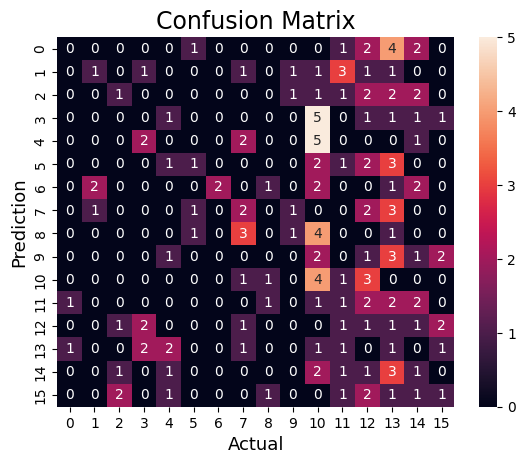

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

#compute the confusion matrix.
cm = confusion_matrix(list_of_labels,list_of_preds)

#Plot the confusion matrix.
sns.heatmap(cm,
            annot=True,
            fmt='g',
            xticklabels=range(16),
            yticklabels=range(16))
plt.ylabel('Prediction',fontsize=13)
plt.xlabel('Actual',fontsize=13)
plt.title('Confusion Matrix',fontsize=17)
plt.show()

## References:

1. [MLOps Repo](https://github.com/graviraja/MLOps-Basics) (For the integration of model and data with PyTorch Lightening)
2. [PyTorch Lightening Docs](https://pytorch-lightning.readthedocs.io/en/stable/index.html) For all the doubts and bugs
3. [My Repo](https://github.com/uakarsh/docformer) For downloading the model and pre-processing steps
4. Unspash for Images
5. Google for other stuffs